# BhuvanFitter — gene-expression distribution fitting

Per-gene tools, imported from `bhuvanfitter.py` (the single source of truth).
`BhuvanFitter` supports two fit models via the same `fit()` / `hist()` interface:

- **`fit("fourparam")`** — fits a 4-parameter Gaussian to the 40-bin histogram by
  ordinary least squares and returns
  `gene, y0, A, x0, w, sumsquarevalue, ti_fourparam_sigma_dist, truncationindex,
  min, max, right, maxheight, rightheight, n_obs, fit_success`. The
  truncation-index metrics use `x_max` (default = observed max):
  **`ti_fourparam_sigma_dist`** = `(x_max − x0) / (w/√2)` and **`truncationindex`**
  = `rightheight / maxheight`, with the fitted curve's interval-minimum subtracted
  from both, so it is **bounded to [0, 1]** (NaN only for a flat fitted curve).
- **`fit("kde")`** — runs a bin-independent Gaussian KDE and detects its modes
  (reusing `gene_peaks`), returning `gene, n_peaks, peaks, bw_method, n_obs,
  fit_success`, where `peaks` is `{value: {"height", "prominence"}}`.

`hist(lines=["fourparam", "kde"])` overlays either/both fitted curves on the
histogram (the KDE scaled to bin counts, with markers at detected peaks), but
only after the corresponding `fit` has been run.

## 1. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The fitting library is the single source of truth (bhuvanfitter.py) — the
# model, the BhuvanFitter class, and gene_peaks all live there.
from bhuvanfitter import BhuvanFitter, gene_peaks

## 2. The 4-Parameter Gaussian Model

$$y = y_0 + A \cdot \exp\!\left(-\left(\frac{x - x_0}{w}\right)^2\right)$$

| Parameter | Meaning |
|---|---|
| `y0` | Baseline offset |
| `A`  | Amplitude (peak height above baseline) |
| `x0` | Centre of the peak |
| `w`  | Width parameter (`w = σ√2`) |

Lives in `bhuvanfitter.py` as the module-level `_fourparam_gaussian` (module
level because `scipy.optimize.curve_fit` needs a plain picklable callable). It is
imported above with `BhuvanFitter` — do **not** redefine it here, or the inline
copy will shadow the import and break (it would need its own `curve_fit` import).

## 3. The `BhuvanFitter` Class

The main interface, imported from `bhuvanfitter.py` (cell 1). It cleans the data,
caches a 40-bin histogram, and dispatches fits through `fit(model)`:

- `fit("fourparam")` — 4-parameter Gaussian by ordinary least squares + the
  truncation-index metrics.
- `fit("kde")` — Gaussian KDE mode detection (reuses `gene_peaks`).

`hist(lines=[...])` overlays any fits that have been run. All analysis logic lives
in the module so the notebook, `generate_fourparam_stats.py`, and
`generate_peaks.py` share one implementation — keep it imported, not redefined.

## 4. Example

A quick synthetic check: fit a Gaussian sample and overlay the fitted curve.

In [21]:
fourparam_df = pd.read_csv("fourparam_table_excluded_at_or_below_-1.csv")
master = pd.read_csv('Supplementary Data 1_csv.csv').set_index('strain')
master = master.T


def select(param):
    """Filtered column for plotting: fit_success genes with 0 < truncationindex < 1,
    NaNs dropped. This is the single place to change the shared filter."""
    mask = (fourparam_df['fit_success'] == True) & (fourparam_df['truncationindex'] > 0) & (fourparam_df['truncationindex'] < 1)
    return fourparam_df.loc[mask, param].dropna()


def plot_param_hist(param, *, color='skyblue', bins=40, log=False):
    """Log-y histogram of `param` over the genes returned by select(). Returns the
    plotted data so callers can print counts / stats."""
    data = select(param)

    # Filtering funnel — mirrors select(), one print per stage.
    after_success = fourparam_df[fourparam_df['fit_success'] == True]
    after_nan = after_success[after_success[param].notna()]
    after_trunc_lower = after_nan[after_nan['truncationindex'] > 0]
    after_trunc_upper = after_trunc_lower[after_trunc_lower['truncationindex'] < 1]
    print(f"Total genes in master:            {master.shape[1]}")
    print(f"Total genes in fourparam_df:      {len(fourparam_df)}")
    print(f"After fit_success == True:        {len(after_success)}")
    print(f"After dropping NaN {param}: {len(after_nan)}")
    print(f"After truncationindex > 0:        {len(after_trunc_lower)}")
    print(f"After truncationindex < 1:        {len(after_trunc_upper)}")

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, color=color, edgecolor='black')
    plt.title(f'Histogram of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency (Log Scale)' if log else 'Frequency')
    if log:
        plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return data

Total genes in master:            25849
Total genes in fourparam_df:      25849
After fit_success == True:        25838
After dropping NaN sumsquarevalue: 25838
After truncationindex > 0:        11077
After truncationindex < 1:        11062


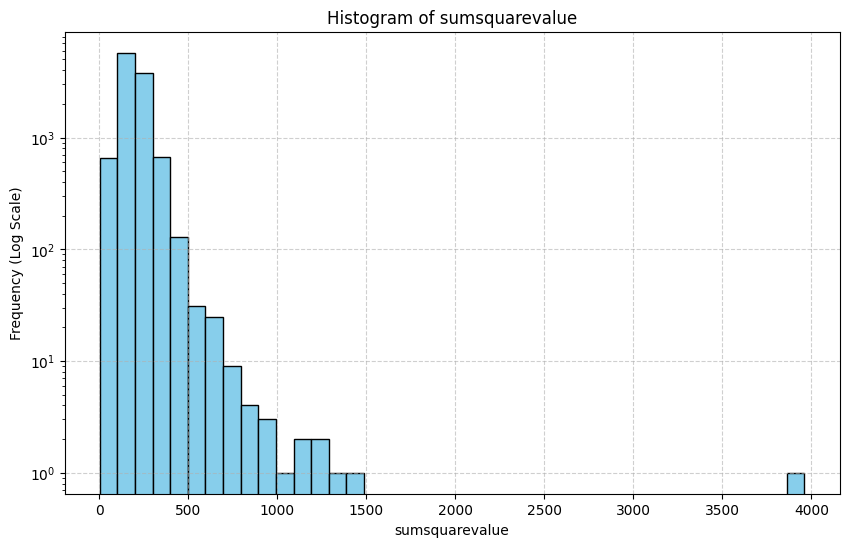

0        281.066268
4        146.262586
5        153.168776
6        124.493575
7        329.172616
            ...    
25838    100.517142
25839    410.363918
25842    217.765740
25847    201.338843
25848    276.690742
Name: sumsquarevalue, Length: 11062, dtype: float64

In [22]:
plot_param_hist('sumsquarevalue', log = True)

Total genes in master:            25849
Total genes in fourparam_df:      25849
After fit_success == True:        25838
After dropping NaN truncationindex: 25819
After truncationindex > 0:        11077
After truncationindex < 1:        11062


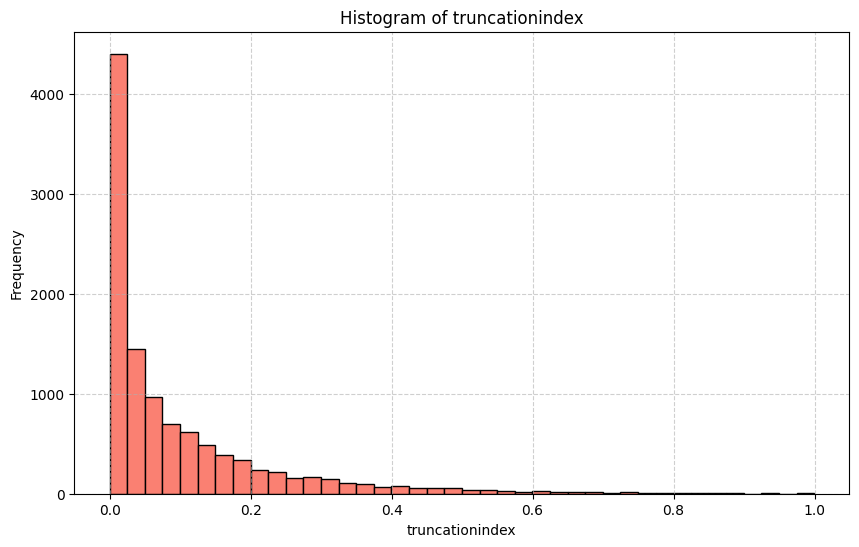

In [23]:
# Distribution of truncationindex across genes that fit successfully.
# truncationindex = rightheight / maxheight, with the fitted curve's interval-minimum
# baseline subtracted from both, so it is bounded to [0, 1] (0 = ceiling at the curve
# minimum, 1 = ceiling at the peak). NaN only for a flat fitted curve.
ti = plot_param_hist('truncationindex', color='salmon', log = False)

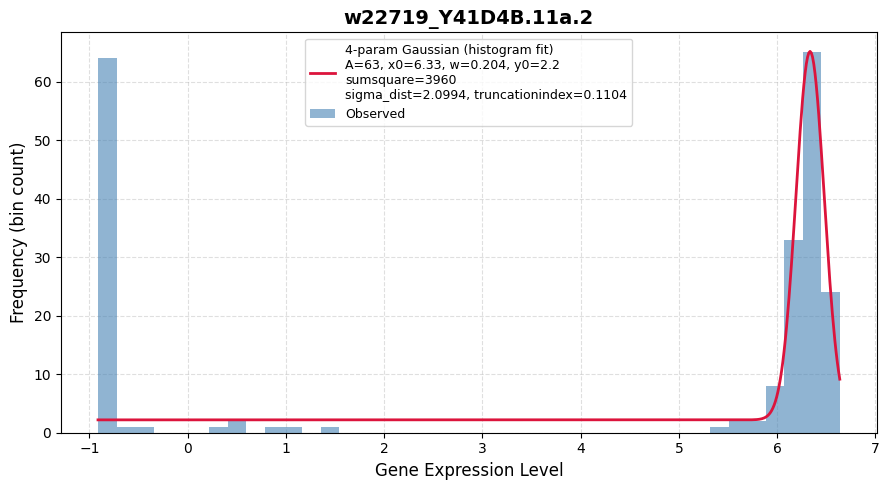

<Axes: title={'center': 'w22719_Y41D4B.11a.2'}, xlabel='Gene Expression Level', ylabel='Frequency (bin count)'>

In [24]:
fitter = BhuvanFitter(master['w22719_Y41D4B.11a.2'], "w22719_Y41D4B.11a.2")
fitter.fit("fourparam")     # runs the 4-param Gaussian
# fitter.fit("kde")           # runs the KDE fit
fitter.hist(lines=["fourparam"])   # overlay both

In [ ]:
trunc = pd.read_excel('Supplementary Data 1 trunc 20250702.xlsx')

avg = trunc['avg'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(avg, bins=40, color='mediumseagreen', edgecolor='black')
plt.title("Histogram of trunc['avg']")
plt.xlabel('avg')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()